In [18]:
# File: analysis.ipynb
# Date: 18 February 2026
# Author: T. Quinn Smith
# Principal Investigator: Zachary A. Szpiech
# Purpose: Analyses conducted in EGGS paper.

import numpy as np
import matplotlib.pyplot as plt
from dtaidistance import dtw

In [19]:
mu=1.25e-8
rho=1e-8
Ne=10000
SEG_SIZES = range(1000000, 10000001, 1000000)
commands = open("gen_segs.sh", "w")
for SEG_SIZE in SEG_SIZES:
    t = 4 * Ne * mu * SEG_SIZE
    r = 4 * Ne * rho * SEG_SIZE
    print(f"mspms 400 1 -t {t} -r {r} {SEG_SIZE-1} --precision 8 | ../EGGS/bin/eggs > seg{SEG_SIZE}.vcf.gz", file=commands)
commands.close()

In [20]:
commands = open("run_segs.sh", "w")
for SEG_SIZE in SEG_SIZES:
    for run in range(1, 11):
        print(f"../EGGS/bin/eggs -b chr1_mathieson2018.vcf.gz < seg{SEG_SIZE}.vcf.gz > seg{SEG_SIZE}_run{run}_beta.vcf.gz", file=commands)
        print(f"../EGGS/bin/eggs -m chr1_mathieson2018.vcf.gz < seg{SEG_SIZE}.vcf.gz > seg{SEG_SIZE}_run{run}_mask.vcf.gz", file=commands)
commands.close()

In [21]:
commands = open("stats_segs.sh", "w")
for SEG_SIZE in SEG_SIZES:
    for run in range(1, 11):
        print(f"../EGGS/bin/eggs --stats -o seg{SEG_SIZE}_run{run}_beta < seg{SEG_SIZE}_run{run}_beta.vcf.gz", file=commands)
        print(f"../EGGS/bin/eggs --stats -o seg{SEG_SIZE}_run{run}_mask < seg{SEG_SIZE}_run{run}_mask.vcf.gz", file=commands)
commands.close()

In [32]:
# Open a loci.tsv file generated by EGGS.
def open_distribution(fileName):
    dis = []
    for line in open(fileName, 'r'):
        fields = line.split()
        if fields[0] != "CHROM":
            dis.append(float(fields[2]))
    return dis

empirical = np.array(open_distribution("chr1_mathieson2018.loci.tsv"))

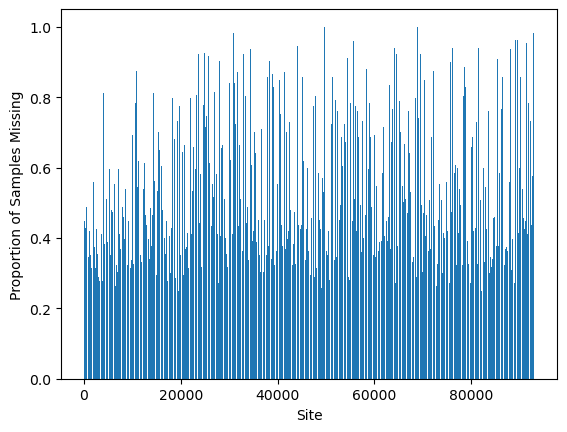

In [33]:
x_positions = range(len(empirical))
plt.bar(x_positions, empirical)
plt.xlabel("Site")
plt.ylabel("Proportion of Samples Missing")
plt.show()

In [34]:
aggMask = []
aggBeta = []
for i, SEG_SIZE in enumerate(SEG_SIZES):
    for run in range(1, 11):
        m = open_distribution(f"seg{SEG_SIZE}_run{run}_mask.loci.tsv")
        b = open_distribution(f"seg{SEG_SIZE}_run{run}_beta.loci.tsv")
        if run == 1:
            aggMask.append(np.zeros(len(m)))
            aggBeta.append(np.zeros(len(b)))
        aggMask[i] += m
        aggBeta[i] += b
    aggMask[i] /= 10
    aggBeta[i] /= 10

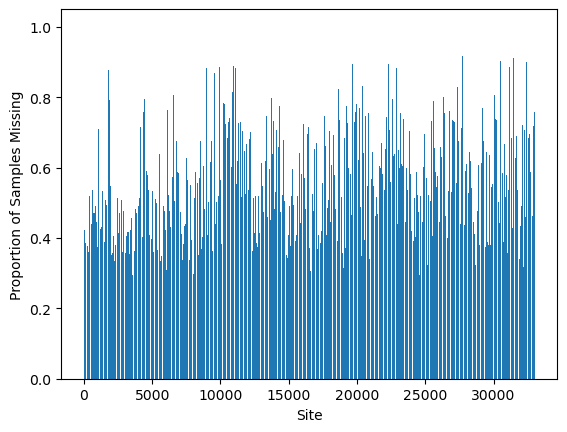

In [35]:
x_positions = range(len(aggMask[9]))
plt.bar(x_positions, aggMask[9])
plt.xlabel("Site")
plt.ylabel("Proportion of Samples Missing")
plt.show()

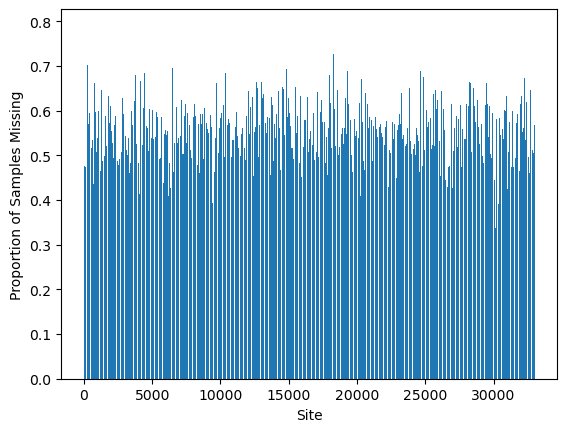

In [36]:
x_positions = range(len(aggBeta[9]))
plt.bar(x_positions, aggBeta[9])
plt.xlabel("Site")
plt.ylabel("Proportion of Samples Missing")
plt.show()

In [37]:
for i, SEG_SIZE in enumerate(SEG_SIZES):
    disBeta = dtw.distance_fast(empirical, aggBeta[i])
    disMask = dtw.distance_fast(empirical, aggMask[i])
    print(SEG_SIZE, len(aggMask[i]), int(len(empirical) / len(aggMask[i])), round(disBeta, 2), round(disMask, 2))

1000000 3327 28 57.49 57.38
2000000 6612 14 55.79 55.02
3000000 9657 9 54.57 53.09
4000000 12659 7 53.46 51.39
5000000 16468 5 52.51 49.2
6000000 19930 4 51.53 47.33
7000000 23012 4 51.08 45.67
8000000 25682 3 50.45 44.29
9000000 29391 3 49.84 42.39
10000000 33023 2 49.27 40.92
